# Algorithmic Recourse

La idea es:
1. Crear un dataset sintético.
2. Entrenar un modelo interpretable.
3. Elegir un caso rechazado.
4. Definir qué variables son accionables y cuáles no.
5. Buscar cambios mínimos que cambien la predicción.
6. Explicar por qué esos cambios funcionan.
7. Extensiónes.

## 1. Importar librerías

In [ ]:
# ============================================
# CELDA 1. IMPORTAR LIBRERÍAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

np.random.seed(42)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Crear un dataset sintético

Usamos un ejemplo artificial para que la lógica sea transparente.


In [ ]:
# ============================================
# CELDA 2. CREAR DATASET SINTÉTICO
# ============================================

n = 1200

age = np.random.randint(21, 61, n)                         # inmutable
education_years = np.random.randint(9, 21, n)             # modificable
income_k = np.clip(np.random.normal(45, 15, n), 10, 100)  # modificable
savings_k = np.clip(np.random.normal(20, 12, n), 0, 80)   # modificable
debt_ratio = np.clip(np.random.beta(2, 4, n), 0.02, 0.95) # modificable
late_payments = np.clip(np.random.poisson(1.7, n), 0, 8)  # modificable
dependents = np.random.randint(0, 5, n)                   # inmutable

noise = np.random.normal(0, 0.8, n)

score = (
    -3.8
    + 0.06 * income_k
    + 0.05 * savings_k
    - 4.5 * debt_ratio
    - 0.45 * late_payments
    + 0.12 * education_years
    - 0.015 * age
    - 0.20 * dependents
    + noise
)

prob = 1 / (1 + np.exp(-score))
approved = (prob > 0.5).astype(int)

df = pd.DataFrame({
    "age": age,
    "education_years": education_years,
    "income_k": np.round(income_k, 1),
    "savings_k": np.round(savings_k, 1),
    "debt_ratio": np.round(debt_ratio, 2),
    "late_payments": late_payments,
    "dependents": dependents,
    "approved": approved
})

print("Primeras filas:")
display(df.head())

print("\nDistribución de la variable objetivo:")
print(df["approved"].value_counts(normalize=True))


Primeras filas:


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,approved
0,59,12,39.200,23.200,0.540,2,2,0
1,49,9,53.300,0.000,0.160,2,0,0
2,35,19,61.400,36.000,0.270,1,0,1
3,28,15,53.000,20.500,0.340,1,1,0
4,41,16,60.200,15.000,0.170,0,2,1



Distribución de la variable objetivo:
approved
0   0.827
1   0.173
Name: proportion, dtype: float64


## 3. Entrenar un modelo interpretable

Usaremos **regresión logística** porque es una buena puerta de entrada para entender recourse.


In [ ]:
# ============================================
# CELDA 3. ENTRENAR MODELO INTERPRETABLE
# ============================================

feature_names = [
    "age",
    "education_years",
    "income_k",
    "savings_k",
    "debt_ratio",
    "late_payments",
    "dependents"
]

X = df[feature_names]
y = df["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print("AUC:", round(roc_auc_score(y_test, test_proba), 3))
print("\nReporte de clasificación:")
print(classification_report(y_test, test_pred))


AUC: 0.934

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       248
           1       0.81      0.56      0.66        52

    accuracy                           0.90       300
   macro avg       0.86      0.76      0.80       300
weighted avg       0.89      0.90      0.89       300



## 4. Interpretar el modelo

Aquí miramos qué variables empujan hacia la aprobación y cuáles hacia el rechazo.


In [ ]:
# ============================================
# CELDA 4. INTERPRETAR COEFICIENTES
# ============================================

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

display(coef_df)

meaningful_steps = {
    "age": 1,
    "education_years": 1,
    "income_k": 5,
    "savings_k": 5,
    "debt_ratio": 0.05,
    "late_payments": 1,
    "dependents": 1
}

rows = []
for f, beta in zip(feature_names, model.coef_[0]):
    step = meaningful_steps[f]
    odds_multiplier = np.exp(beta * step)
    rows.append({
        "feature": f,
        "step_used": step,
        "beta": beta,
        "odds_multiplier_for_step": odds_multiplier
    })

interpret_df = pd.DataFrame(rows).sort_values("beta", ascending=False)
display(interpret_df)

print("Lectura rápida:")
print("- Coeficiente positivo: subir esa variable aumenta la probabilidad de aprobación.")
print("- Coeficiente negativo: subir esa variable reduce la probabilidad de aprobación.")


,feature,coefficient
1,education_years,0.271
3,savings_k,0.121
2,income_k,0.117
0,age,-0.016
6,dependents,-0.337
5,late_payments,-0.840
4,debt_ratio,-4.937


,feature,step_used,beta,odds_multiplier_for_step
1,education_years,1.000,0.271,1.311
3,savings_k,5.000,0.121,1.828
2,income_k,5.000,0.117,1.795
0,age,1.000,-0.016,0.984
6,dependents,1.000,-0.337,0.714
5,late_payments,1.000,-0.840,0.432
4,debt_ratio,0.050,-4.937,0.781


Lectura rápida:
- Coeficiente positivo: subir esa variable aumenta la probabilidad de aprobación.
- Coeficiente negativo: subir esa variable reduce la probabilidad de aprobación.


## 5. Elegir un caso rechazado para hacer recourse

In [ ]:
# ============================================
# CELDA 5. ESCOGER UNA PERSONA RECHAZADA
# ============================================

test_results = X_test.copy()
test_results["true_label"] = y_test.values
test_results["pred_prob"] = test_proba
test_results["pred_label"] = test_pred

rejected = test_results[test_results["pred_label"] == 0].sort_values("pred_prob", ascending=False)

print("Algunos casos rechazados cercanos al umbral:")
display(rejected.head(10))

person_index = rejected.index[6]
person = rejected.loc[person_index, feature_names].copy()

print(f"Índice seleccionado: {person_index}")
display(person.to_frame(name="current_value"))

current_prob = model.predict_proba(pd.DataFrame([person]))[0, 1]
print("Probabilidad actual de aprobación:", round(current_prob, 4))
print("Predicción actual:", int(current_prob >= 0.5))


Algunos casos rechazados cercanos al umbral:


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,true_label,pred_prob,pred_label
36,38,19,59.200,21.200,0.190,2,3,1,0.484,0
253,45,19,31.200,31.500,0.130,1,0,0,0.484,0
707,37,18,56.300,19.600,0.270,1,2,1,0.482,0
505,32,16,63.000,22.700,0.600,0,2,1,0.459,0
84,44,15,67.200,18.100,0.330,1,2,1,0.451,0
198,53,17,50.300,37.200,0.650,0,2,0,0.447,0
305,43,10,47.400,28.300,0.090,0,1,1,0.435,0
788,40,20,44.900,18.500,0.060,1,3,0,0.415,0
868,40,20,32.100,20.700,0.130,0,1,1,0.399,0
500,51,15,64.100,26.000,0.370,2,1,0,0.397,0


Índice seleccionado: 305


,current_value
age,43.000
education_years,10.000
income_k,47.400
savings_k,28.300
debt_ratio,0.090
late_payments,0.000
dependents,1.000


Probabilidad actual de aprobación: 0.4347
Predicción actual: 0


## 6. Definir acción, restricciones y costo

Esta es la médula del recourse: no todo se puede cambiar, no todo cambia en cualquier dirección y no todo cuesta lo mismo.


In [ ]:
# ============================================
# CELDA 6. DEFINIR REGLAS DE ACTIONABILITY
# ============================================

immutable_features = ["age", "dependents"]

actionable_features = {
    "education_years": {
        "direction": "increase",
        "step": 1,
        "max_change": 4,
        "min_value": 9,
        "max_value": 20,
        "unit_cost": 1.0
    },
    "income_k": {
        "direction": "increase",
        "step": 5,
        "max_change": 40,
        "min_value": 10,
        "max_value": 100,
        "unit_cost": 1.0
    },
    "savings_k": {
        "direction": "increase",
        "step": 5,
        "max_change": 30,
        "min_value": 0,
        "max_value": 80,
        "unit_cost": 0.8
    },
    "debt_ratio": {
        "direction": "decrease",
        "step": 0.05,
        "max_change": 0.30,
        "min_value": 0.0,
        "max_value": 0.95,
        "unit_cost": 1.5
    },
    "late_payments": {
        "direction": "decrease",
        "step": 1,
        "max_change": 3,
        "min_value": 0,
        "max_value": 8,
        "unit_cost": 1.2
    }
}

print("Variables inmutables:", immutable_features)
print("\nVariables accionables:")
for k, v in actionable_features.items():
    print(k, "->", v)


Variables inmutables: ['age', 'dependents']

Variables accionables:
education_years -> {'direction': 'increase', 'step': 1, 'max_change': 4, 'min_value': 9, 'max_value': 20, 'unit_cost': 1.0}
income_k -> {'direction': 'increase', 'step': 5, 'max_change': 40, 'min_value': 10, 'max_value': 100, 'unit_cost': 1.0}
savings_k -> {'direction': 'increase', 'step': 5, 'max_change': 30, 'min_value': 0, 'max_value': 80, 'unit_cost': 0.8}
debt_ratio -> {'direction': 'decrease', 'step': 0.05, 'max_change': 0.3, 'min_value': 0.0, 'max_value': 0.95, 'unit_cost': 1.5}
late_payments -> {'direction': 'decrease', 'step': 1, 'max_change': 3, 'min_value': 0, 'max_value': 8, 'unit_cost': 1.2}


## Definición de reglas de *actionability*

En esta sección no se entrena el modelo ni se generan todavía recomendaciones. Aquí se definen las **reglas del juego** que seguirá el procedimiento de *algorithmic recourse*.

La idea central del recourse no es solamente preguntarse **qué variables deberían cambiar para modificar la predicción**, sino también **qué cambios son realmente posibles, en qué dirección pueden ocurrir, cuánto pueden variar y qué costo tendría hacerlo**.

### Variables inmutables

Las variables `age` y `dependents` se consideran **inmutables**, es decir, pueden influir en la predicción del modelo, pero **no pueden ser modificadas** por el mecanismo de recourse.

En este ejemplo:

- `age` representa la edad.
- `dependents` representa el número de dependientes.

La razón es conceptual: no sería razonable que una recomendación de recourse dijera “disminuya su edad” o “modifique su número de dependientes” como si fueran decisiones operativas inmediatas.

### Variables accionables

Las variables incluidas en `actionable_features` son aquellas que **sí pueden ser ajustadas** al buscar una ruta para cambiar la predicción del modelo. Para cada una se define un conjunto de reglas:

- **`direction`**: indica si la variable solo puede aumentar (`increase`) o solo puede disminuir (`decrease`).
- **`step`**: define el tamaño mínimo del cambio que el algoritmo considerará.
- **`max_change`**: limita cuánto puede modificarse la variable con respecto al valor original del caso.
- **`min_value` y `max_value`**: fijan límites absolutos razonables para la variable.
- **`unit_cost`**: representa el costo relativo de modificar esa variable. No tiene que interpretarse necesariamente como dinero real, sino como una medida abstracta de esfuerzo, dificultad o factibilidad.

### Interpretación de cada variable

#### `education_years`

Esta configuración indica que los años de educación solo pueden **aumentar**, en pasos de **1 año**, con un máximo de **4 años adicionales**, y dentro del rango **9 a 20 años**. Cada aumento de un año tiene un costo unitario de **1.0**.

#### `income_k`

El ingreso solo puede **aumentar**, en bloques de **5 unidades**, hasta un máximo de **40 unidades adicionales**, y siempre dentro del rango **10 a 100**. Cada bloque adicional tiene un costo unitario de **1.0**.

#### `savings_k`

Los ahorros solo pueden **aumentar**, en bloques de **5 unidades**, hasta un máximo de **30 unidades**, y dentro del rango **0 a 80**. En este caso, el costo unitario es **0.8**, lo que sugiere que, para el algoritmo, aumentar ahorros es relativamente menos costoso que modificar otras variables.

#### `debt_ratio`

El ratio de deuda solo puede **disminuir**, en pasos de **0.05**, con una mejora máxima de **0.30**, y manteniéndose dentro del rango **0.0 a 0.95**. Su costo unitario es **1.5**, lo que refleja que reducir deuda es tratado como un cambio relativamente más difícil o costoso.

#### `late_payments`

Los pagos tardíos solo pueden **disminuir**, de **uno en uno**, con una mejora máxima de **3 unidades**, dentro del rango **0 a 8**. El costo unitario de esta modificación es **1.2**.

### Sentido metodológico de esta sección

El objetivo de estas reglas es evitar que el recourse produzca recomendaciones irreales, arbitrarias o absurdas. Sin estas restricciones, el algoritmo podría sugerir cambios como reducir la edad, eliminar completamente la deuda de manera instantánea o aumentar años de estudio en magnitudes poco plausibles.

Por tanto, esta sección cumple una función crucial: **convertir la búsqueda de recourse en un procedimiento controlado, interpretable y más cercano a cambios que podrían considerarse razonables en un contexto real**.

## 7. Buscar recourse por fuerza bruta explicable

La estrategia aquí es deliberadamente docente: búsqueda por grilla. No es la más elegante para producción, pero sí una de las más transparentes.


In [ ]:
# ============================================
# CELDA 7. FUNCIONES DE RECOURSE
# ============================================

def build_candidate_values(current_value, cfg):
    """
    Construye los posibles valores permitidos para una variable accionable.
    """
    step = cfg["step"]
    max_change = cfg["max_change"]

    if cfg["direction"] == "increase":
        upper = min(current_value + max_change, cfg["max_value"])
        values = np.arange(current_value, upper + 1e-9, step)
    else:
        lower = max(current_value - max_change, cfg["min_value"])
        values = np.arange(lower, current_value + 1e-9, step)

    values = np.round(values, 2)
    values = sorted(set(values))
    return values


def recourse_cost(original, candidate, actionable_features):
    """
    Calcula el costo total del cambio.
    """
    total = 0.0
    detail = {}

    for f, cfg in actionable_features.items():
        if cfg["direction"] == "increase":
            change = max(candidate[f] - original[f], 0)
        else:
            change = max(original[f] - candidate[f], 0)

        units = change / cfg["step"]
        feature_cost = units * cfg["unit_cost"]

        detail[f] = round(feature_cost, 3)
        total += feature_cost

    return round(total, 3), detail


def find_recourse(person_row, model, feature_names, actionable_features):
    """
    Busca recomendaciones accionables que cambien la predicción.
    """
    value_grid = {
        f: build_candidate_values(float(person_row[f]), cfg)
        for f, cfg in actionable_features.items()
    }

    candidates = []

    for values in product(*[value_grid[f] for f in actionable_features.keys()]):
        candidate = person_row.copy()

        for f, v in zip(actionable_features.keys(), values):
            candidate[f] = v

        x_candidate = pd.DataFrame([candidate[feature_names]])
        prob = model.predict_proba(x_candidate)[0, 1]
        pred = int(prob >= 0.5)

        if pred == 1:
            total_cost, cost_detail = recourse_cost(person_row, candidate, actionable_features)

            candidates.append({
                "prob_approve": round(float(prob), 4),
                "total_cost": total_cost,
                "candidate": candidate.copy(),
                "cost_detail": cost_detail
            })

    if len(candidates) == 0:
        return None, []

    candidates = sorted(candidates, key=lambda x: (x["total_cost"], -x["prob_approve"]))
    best = candidates[0]

    return best, candidates


best_recourse, all_candidates = find_recourse(
    person_row=person,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features
)

print("Número de soluciones de recourse encontradas:", len(all_candidates))
print("\nMejor solución encontrada:")
print(best_recourse)


Número de soluciones de recourse encontradas: 629

Mejor solución encontrada:
{'prob_approve': 0.6313, 'total_cost': np.float64(2.0), 'candidate': age               43.000
education_years   10.000
income_k          47.400
savings_k         33.300
debt_ratio         0.050
late_payments      0.000
dependents         1.000
Name: 305, dtype: float64, 'cost_detail': {'education_years': np.float64(0.0), 'income_k': np.float64(0.0), 'savings_k': np.float64(0.8), 'debt_ratio': np.float64(1.2), 'late_payments': np.float64(0.0)}}


## Funciones de *recourse* y lectura de los resultados

En esta sección ya no se definen solo las reglas del juego, sino que se implementa el mecanismo que busca **qué cambios concretos podrían hacer que una persona pase de una predicción negativa a una positiva**.

La lógica general de esta celda es la siguiente:

1. Para cada variable accionable, se generan los valores que serían permitidos según las restricciones definidas antes.
2. Luego se construyen todas las combinaciones posibles entre esos valores.
3. Cada combinación se evalúa con el modelo.
4. Se conservan únicamente las combinaciones que logran cambiar la predicción a la clase positiva.
5. Finalmente, esas soluciones se ordenan por costo, y se selecciona la más barata.

### Función `build_candidate_values`

Esta función construye los posibles valores que puede tomar una variable accionable para un caso particular.

Su entrada es:
- `current_value`: el valor actual de la variable para la persona analizada.
- `cfg`: la configuración de esa variable, donde están definidas la dirección del cambio, el tamaño del paso, el máximo cambio permitido y los límites mínimo y máximo.

La lógica es:

- Si la variable solo puede **aumentar**, entonces se generan valores desde el valor actual hasta el máximo permitido.
- Si la variable solo puede **disminuir**, entonces se generan valores desde el mínimo permitido hasta el valor actual.
- Después, esos valores se redondean y se ordenan.

En otras palabras, esta función responde a la pregunta: **“para esta variable y esta persona, qué valores se pueden considerar como cambios válidos?”**

Por ejemplo, si una persona tiene un `debt_ratio = 0.10`, y la regla dice que puede disminuir en pasos de `0.05` con un `max_change = 0.30`, entonces se probarían valores como `0.00`, `0.05` y `0.10`, siempre respetando el mínimo definido.

### Función `recourse_cost`

Esta función calcula el costo total de una recomendación.

Compara:
- el caso original (`original`)
- con un caso modificado (`candidate`)

y revisa, para cada variable accionable, cuánto cambió realmente.

La lógica es:

- Si la variable solo puede subir, el cambio se calcula como `candidate - original`.
- Si la variable solo puede bajar, el cambio se calcula como `original - candidate`.

Luego, ese cambio se divide por el tamaño del paso (`step`) para saber cuántas unidades de cambio hubo, y se multiplica por el costo unitario (`unit_cost`).

La función devuelve dos cosas:

- `total_cost`: el costo total acumulado de toda la recomendación.
- `detail`: un diccionario con el costo aportado por cada variable.

Esto permite no solo saber cuál recomendación funciona, sino también **cuál funciona con menor esfuerzo relativo**.

### Función `find_recourse`

Esta es la función principal. Su tarea es buscar recomendaciones accionables que cambien la predicción del modelo.

Su funcionamiento puede resumirse así:

#### 1. Construcción de la grilla de valores posibles

Para cada variable accionable se generan todos los valores permitidos mediante `build_candidate_values`.

El resultado es una especie de “grilla” de posibilidades. Por ejemplo:
- distintos niveles posibles de ahorro,
- distintos niveles posibles de deuda,
- distintos niveles posibles de mora,
- etc.

#### 2. Generación de combinaciones

Con `product(...)` se construyen todas las combinaciones posibles entre esas listas de valores.

Esto significa que el algoritmo no evalúa una variable aislada, sino todas las combinaciones posibles entre las variables accionables.

#### 3. Evaluación con el modelo

Cada combinación se convierte en un nuevo caso hipotético y se le pide al modelo su probabilidad de pertenecer a la clase positiva.

Luego se aplica la regla:

- si `prob >= 0.5`, la combinación se considera una solución válida de recourse;
- si no, se descarta.

#### 4. Cálculo de costo

Si una combinación logra cambiar la predicción, se calcula su costo usando `recourse_cost`.

Entonces se guarda:
- la nueva probabilidad de aprobación,
- el costo total,
- el caso modificado,
- y el detalle del costo por variable.

#### 5. Ordenamiento de soluciones

Cuando termina la búsqueda:

- si no se encontró ninguna solución, la función devuelve `None` y una lista vacía;
- si sí se encontraron soluciones, se ordenan primero por menor costo y, en caso de empate, por mayor probabilidad de aprobación.

Finalmente:
- `best` es la mejor solución encontrada;
- `candidates` contiene todas las soluciones válidas.

### Interpretación del resultado obtenido

El resultado mostrado fue:

- **Número de soluciones de recourse encontradas: 629**
- y luego una mejor solución con:
  - `prob_approve = 0.6313`
  - `total_cost = 2.0`

Esto significa que:

#### 1. Se encontraron 629 combinaciones válidas

El algoritmo exploró muchas combinaciones posibles entre las variables accionables y encontró **629 combinaciones que sí logran cambiar la predicción** del modelo a la clase positiva.

Eso es importante porque muestra que no existe una única ruta posible. Hay varias maneras de “cruzar el umbral”.

#### 2. La mejor solución es la de menor costo

Entre esas 629 soluciones, el algoritmo eligió la que tiene menor costo total.

La probabilidad final de aprobación para esa solución es `0.6313`, es decir, una vez aplicados los cambios sugeridos, el caso no solo pasa el umbral de `0.5`, sino que queda con cierto margen por encima.

#### 3. El costo total es `2.0`

Esto significa que, bajo la métrica de costos definida en el notebook, el conjunto total de cambios requeridos equivale a un esfuerzo relativo de `2.0`.

No debe leerse necesariamente como dinero real. Es una medida abstracta de esfuerzo o dificultad.

### Lectura del caso recomendado

La mejor solución encontrada muestra un nuevo caso hipotético con estos valores:

- `age = 43`
- `education_years = 10`
- `income_k = 47.4`
- `savings_k = 33.3`
- `debt_ratio = 0.05`
- `late_payments = 0`
- `dependents = 1`

Aquí conviene notar algo importante:

- `age` y `dependents` no cambiaron, porque son inmutables.
- algunas variables accionables sí cambiaron.
- otras quedaron igual, lo que indica que no era necesario modificarlas para lograr una solución de bajo costo.

### Interpretación del `cost_detail`

El detalle del costo fue:

- `education_years: 0.0`
- `income_k: 0.0`
- `savings_k: 0.8`
- `debt_ratio: 1.2`
- `late_payments: 0.0`

Esto significa que la mejor recomendación, en este caso, se apoyó principalmente en dos cambios:

- una mejora en `savings_k`
- una mejora en `debt_ratio`

y no necesitó modificar:
- `education_years`
- `income_k`
- `late_payments`

En términos sustantivos, la lectura sería algo como esta:

**para esta persona, el modelo considera suficiente una combinación de mayor ahorro y menor ratio de deuda para cambiar la predicción a positiva, sin necesidad de tocar otras variables accionables.**

### Por qué `savings_k` cuesta 0.8 y `debt_ratio` cuesta 1.2

Esto viene directamente de las reglas definidas antes.

- `savings_k` tenía `unit_cost = 0.8`
- `debt_ratio` tenía `unit_cost = 1.5`, con pasos de `0.05`

Así, el costo total refleja cuántos pasos se dio en cada variable y cuánto cuesta cada paso.

Por ejemplo:
- un pequeño aumento en ahorros puede costar `0.8`
- una reducción moderada de deuda puede costar `1.2`
- la suma da `2.0`

## 8. Mostrar el recourse de forma interpretable

In [ ]:
# ============================================
# CELDA 8. RESUMEN HUMANO DEL RECOURSE
# ============================================

if best_recourse is None:
    print("No se encontró recourse factible bajo las restricciones dadas.")
else:
    candidate = best_recourse["candidate"]

    summary_rows = []
    for f in feature_names:
        summary_rows.append({
            "feature": f,
            "original": person[f],
            "recommended": candidate[f],
            "delta": round(float(candidate[f] - person[f]), 3)
        })

    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)

    print("Probabilidad original:",
          round(model.predict_proba(pd.DataFrame([person]))[0, 1], 4))
    print("Probabilidad con recourse:",
          round(model.predict_proba(pd.DataFrame([candidate[feature_names]]))[0, 1], 4))
    print("Costo total:", best_recourse["total_cost"])
    print("Detalle del costo:", best_recourse["cost_detail"])


,feature,original,recommended,delta
0,age,43.000,43.000,0.000
1,education_years,10.000,10.000,0.000
2,income_k,47.400,47.400,0.000
3,savings_k,28.300,33.300,5.000
4,debt_ratio,0.090,0.050,-0.040
5,late_payments,0.000,0.000,0.000
6,dependents,1.000,1.000,0.000


Probabilidad original: 0.4347
Probabilidad con recourse: 0.6313
Costo total: 2.0
Detalle del costo: {'education_years': np.float64(0.0), 'income_k': np.float64(0.0), 'savings_k': np.float64(0.8), 'debt_ratio': np.float64(1.2), 'late_payments': np.float64(0.0)}


## Resumen simple del *recourse* e interpretación de los resultados

Esta sección tiene como objetivo traducir la mejor solución de *recourse* a un formato más fácil de leer. Mientras que la celda anterior encontró matemáticamente la mejor combinación de cambios, aquí se presenta esa solución de manera comparativa entre el caso original y el caso recomendado.

La lógica de esta celda es la siguiente:

1. Verifica si se encontró una solución de *recourse*.
2. Si no existe una solución factible, imprime un mensaje indicándolo.
3. Si sí existe una solución, construye una tabla comparando, para cada variable, el valor original, el valor recomendado y la diferencia entre ambos.
4. Finalmente, muestra la probabilidad original, la probabilidad después del *recourse*, el costo total y el detalle del costo por variable.

### Interpretación de la tabla mostrada

La tabla obtenida fue la siguiente:

- `age`: de `43.000` a `43.000`, cambio `0.000`
- `education_years`: de `10.000` a `10.000`, cambio `0.000`
- `income_k`: de `47.400` a `47.400`, cambio `0.000`
- `savings_k`: de `28.300` a `33.300`, cambio `5.000`
- `debt_ratio`: de `0.090` a `0.050`, cambio `-0.040`
- `late_payments`: de `0.000` a `0.000`, cambio `0.000`
- `dependents`: de `1.000` a `1.000`, cambio `0.000`

La lectura sustantiva es la siguiente:

- `age` no cambió, lo cual es consistente con el hecho de que es una variable inmutable.
- `dependents` tampoco cambió, también porque es inmutable.
- `education_years` no necesitó modificarse.
- `income_k` tampoco necesitó modificarse.
- `late_payments` ya estaba en `0`, así que no había margen de mejora en esa variable.
- Los únicos cambios necesarios fueron:
  - aumentar `savings_k` en `5.0`
  - reducir `debt_ratio` en `0.04`

En otras palabras, la recomendación mínima que encontró el algoritmo fue:

**aumentar el nivel de ahorro y reducir ligeramente el ratio de deuda.**

### Interpretación de las probabilidades

Se imprimieron dos valores:

- **Probabilidad original: `0.4347`**
- **Probabilidad con recourse: `0.6313`**

Esto significa que, antes de aplicar la recomendación, el modelo estimaba que la persona tenía una probabilidad de `0.4347` de pertenecer a la clase positiva. Como esa probabilidad estaba por debajo del umbral de decisión `0.5`, la persona era clasificada en la clase negativa.

Después de aplicar la recomendación, la probabilidad sube a `0.6313`, lo cual ya supera claramente el umbral. Por tanto, el caso pasa a ser clasificado como positivo.

La interpretación práctica es:

**los cambios sugeridos no solo logran cruzar el umbral, sino que dejan al caso con cierto margen de seguridad por encima de 0.5.**

### Interpretación del costo total

El costo total reportado fue:

**`2.0`**

Este valor resume el esfuerzo relativo asociado a la recomendación completa, según los costos definidos previamente en las reglas de *actionability*.

## 9. Ver varias alternativas, no solo una

Esto es importante: muchas veces hay más de una ruta para cambiar la predicción.


In [ ]:
# ============================================
# CELDA 9. TOP ALTERNATIVAS DE RECOURSE
# ============================================

def build_top_recourse_table(person_row, candidates, top_n=5):
    rows = []

    for i, c in enumerate(candidates[:top_n], start=1):
        row = {
            "rank": i,
            "prob_approve": c["prob_approve"],
            "total_cost": c["total_cost"]
        }

        for f in actionable_features.keys():
            row[f"{f}_new"] = c["candidate"][f]
            row[f"{f}_delta"] = round(float(c["candidate"][f] - person_row[f]), 3)

        rows.append(row)

    return pd.DataFrame(rows)

top_table = build_top_recourse_table(person, all_candidates, top_n=10)
display(top_table)


,rank,prob_approve,total_cost,education_years_new,education_years_delta,income_k_new,income_k_delta,savings_k_new,savings_k_delta,debt_ratio_new,debt_ratio_delta,late_payments_new,late_payments_delta
0,1,0.631,2.000,10.000,0.000,47.400,0.000,33.300,5.000,0.050,-0.040,0.000,0.000
1,2,0.627,2.200,10.000,0.000,52.400,5.000,28.300,0.000,0.050,-0.040,0.000,0.000
2,3,0.551,2.200,11.000,1.000,47.400,0.000,28.300,0.000,0.050,-0.040,0.000,0.000
3,4,0.545,2.700,10.000,0.000,47.400,0.000,28.300,0.000,0.000,-0.090,0.000,0.000
4,5,0.758,2.800,10.000,0.000,47.400,0.000,38.300,10.000,0.050,-0.040,0.000,0.000
5,6,0.755,3.000,10.000,0.000,52.400,5.000,33.300,5.000,0.050,-0.040,0.000,0.000
6,7,0.692,3.000,11.000,1.000,47.400,0.000,33.300,5.000,0.050,-0.040,0.000,0.000
7,8,0.751,3.200,10.000,0.000,57.400,10.000,28.300,0.000,0.050,-0.040,0.000,0.000
8,9,0.688,3.200,11.000,1.000,52.400,5.000,28.300,0.000,0.050,-0.040,0.000,0.000
9,10,0.617,3.200,12.000,2.000,47.400,0.000,28.300,0.000,0.050,-0.040,0.000,0.000


## 10. Explicar por qué funciona el cambio

Como el modelo es lineal en el logit, podemos descomponer el score en contribuciones por variable.


In [ ]:
# ============================================
# CELDA 10. EXPLICAR CONTRIBUCIONES AL SCORE
# ============================================

coef_map = dict(zip(feature_names, model.coef_[0]))
intercept = model.intercept_[0]

def contribution_table(row, coef_map, intercept):
    rows = []
    total = intercept

    rows.append({
        "feature": "INTERCEPT",
        "value": np.nan,
        "coefficient": np.nan,
        "contribution": intercept
    })

    for f in feature_names:
        contrib = row[f] * coef_map[f]
        total += contrib
        rows.append({
            "feature": f,
            "value": row[f],
            "coefficient": coef_map[f],
            "contribution": contrib
        })

    out = pd.DataFrame(rows)
    return out, total

before_contrib, before_score = contribution_table(person, coef_map, intercept)
after_contrib, after_score = contribution_table(best_recourse["candidate"], coef_map, intercept)

compare = before_contrib[["feature", "contribution"]].merge(
    after_contrib[["feature", "contribution"]],
    on="feature",
    suffixes=("_before", "_after")
)

compare["delta_contribution"] = compare["contribution_after"] - compare["contribution_before"]

print("Contribuciones antes:")
display(before_contrib)

print("Contribuciones después:")
display(after_contrib)

print("Comparación:")
display(compare)

print("Score logit antes:", round(before_score, 4))
print("Score logit después:", round(after_score, 4))

print("\nLectura:")
print("- Si el score sube por encima del umbral implícito, la predicción cambia.")
print("- El recourse funciona porque algunas variables accionables empujan el score hacia arriba.")


Contribuciones antes:


,feature,value,coefficient,contribution
0,INTERCEPT,NaN,NaN,-10.465
1,age,43.000,-0.016,-0.688
2,education_years,10.000,0.271,2.711
3,income_k,47.400,0.117,5.548
4,savings_k,28.300,0.121,3.413
5,debt_ratio,0.090,-4.937,-0.444
6,late_payments,0.000,-0.840,-0.000
7,dependents,1.000,-0.337,-0.337


Contribuciones después:


,feature,value,coefficient,contribution
0,INTERCEPT,NaN,NaN,-10.465
1,age,43.000,-0.016,-0.688
2,education_years,10.000,0.271,2.711
3,income_k,47.400,0.117,5.548
4,savings_k,33.300,0.121,4.016
5,debt_ratio,0.050,-4.937,-0.247
6,late_payments,0.000,-0.840,-0.000
7,dependents,1.000,-0.337,-0.337


Comparación:


,feature,contribution_before,contribution_after,delta_contribution
0,INTERCEPT,-10.465,-10.465,0.000
1,age,-0.688,-0.688,0.000
2,education_years,2.711,2.711,0.000
3,income_k,5.548,5.548,0.000
4,savings_k,3.413,4.016,0.603
5,debt_ratio,-0.444,-0.247,0.197
6,late_payments,-0.000,-0.000,0.000
7,dependents,-0.337,-0.337,0.000


Score logit antes: -0.2626
Score logit después: 0.5378

Lectura:
- Si el score sube por encima del umbral implícito, la predicción cambia.
- El recourse funciona porque algunas variables accionables empujan el score hacia arriba.


## Explicación de contribuciones al *score* y lectura de los resultados

Esta sección tiene como objetivo explicar **por qué** la recomendación de *recourse* funciona desde el punto de vista interno del modelo. Mientras que las celdas anteriores mostraban qué variables cambiaban y cuánto costaba hacerlo, aquí se analiza **cómo cada variable aporta al valor del score lineal** de la regresión logística.

La idea central es que, en una regresión logística, antes de transformar el resultado en una probabilidad, el modelo calcula primero un **score lineal** o **logit**. Ese score se obtiene sumando:

- un intercepto,
- más la contribución de cada variable,
- donde cada contribución es el valor de la variable multiplicado por su coeficiente.

En términos generales, la fórmula que se está usando es:

**score = intercepto + Σ(valor de la variable × coeficiente)**

Luego, ese score se transforma en probabilidad. Si el score aumenta lo suficiente, la probabilidad también aumenta, y eventualmente la predicción puede cambiar de negativa a positiva.

### Qué hace el código

#### 1. Construcción del mapa de coeficientes

La instrucción que crea `coef_map` organiza los coeficientes del modelo en un diccionario, asociando cada variable con su coeficiente estimado. El intercepto se guarda por separado en `intercept`.

Esto permite identificar cuánto pesa cada variable en el cálculo del score.

#### 2. Función `contribution_table`

La función `contribution_table` recibe:

- una fila de datos (`row`),
- los coeficientes del modelo (`coef_map`),
- y el intercepto.

Su tarea es construir una tabla con cuatro columnas:

- `feature`: el nombre de la variable,
- `value`: el valor de esa variable en el caso analizado,
- `coefficient`: el coeficiente estimado por el modelo,
- `contribution`: el producto entre valor y coeficiente.

Además, la función suma todas esas contribuciones al intercepto y devuelve también el score total.

En otras palabras, esta función responde a la pregunta:

**“¿cuánto está aportando cada variable al score final del modelo?”**

#### 3. Cálculo antes y después del *recourse*

Luego se calculan dos tablas:

- `before_contrib`: las contribuciones del caso original,
- `after_contrib`: las contribuciones del caso modificado por el *recourse*.

Con esto se puede comparar cómo cambia el score cuando se aplican las recomendaciones.

#### 4. Construcción de la tabla comparativa

Después se construye `compare`, una tabla que muestra:

- la contribución antes,
- la contribución después,
- y la diferencia entre ambas (`delta_contribution`).

Esta tabla es especialmente útil porque permite identificar **qué variables explican el cambio de la predicción**.

### Interpretación de las contribuciones antes del *recourse*

En el caso original, las contribuciones fueron aproximadamente las siguientes:

- `INTERCEPT`: `-10.465`
- `age`: `-0.688`
- `education_years`: `2.711`
- `income_k`: `5.548`
- `savings_k`: `3.413`
- `debt_ratio`: `-0.444`
- `late_payments`: `-0.000`
- `dependents`: `-0.337`

Al sumar todo esto se obtiene:

**Score logit antes: `-0.2626`**

La interpretación es la siguiente:

- El intercepto parte de un valor fuertemente negativo.
- Algunas variables empujan el score hacia arriba, especialmente:
  - `income_k`
  - `savings_k`
  - `education_years`
- Otras lo empujan hacia abajo, como:
  - `age`
  - `debt_ratio`
  - `dependents`

En el balance total, el score queda en `-0.2626`, es decir, todavía por debajo del punto a partir del cual la probabilidad supera el umbral de decisión.

Por eso, antes del *recourse*, la persona era clasificada en la clase negativa.

### Interpretación de las contribuciones después del *recourse*

En el caso modificado por el *recourse*, las contribuciones fueron:

- `INTERCEPT`: `-10.465`
- `age`: `-0.688`
- `education_years`: `2.711`
- `income_k`: `5.548`
- `savings_k`: `4.016`
- `debt_ratio`: `-0.247`
- `late_payments`: `-0.000`
- `dependents`: `-0.337`

La suma total da:

**Score logit después: `0.5378`**

Esto significa que el *recourse* logró mover el score desde un valor negativo a un valor positivo. Ese cambio es suficiente para aumentar la probabilidad y cambiar la clasificación del caso.

### Interpretación de la tabla de comparación

La tabla comparativa mostró que solo dos variables modificaron realmente su contribución:

- `savings_k`: pasó de `3.413` a `4.016`, con un cambio de `+0.603`
- `debt_ratio`: pasó de `-0.444` a `-0.247`, con un cambio de `+0.197`

Las demás variables quedaron exactamente igual, por lo que su contribución no cambió.

Esto permite una lectura muy clara:

- aumentar los ahorros hizo que `savings_k` aportara más positivamente al score;
- reducir el ratio de deuda hizo que `debt_ratio` penalizara menos al caso;
- la combinación de ambos cambios elevó el score total lo suficiente como para cambiar la predicción.

### Qué significa que `debt_ratio` mejore aunque siga siendo negativo

Puede parecer extraño que `debt_ratio` siga teniendo una contribución negativa incluso después del *recourse*. Sin embargo, esto tiene sentido.

El coeficiente de `debt_ratio` es negativo, por lo que cualquier valor positivo de esa variable genera una contribución negativa. Pero al reducir el ratio de deuda de `0.090` a `0.050`, esa penalización se hace menor:

- antes: `-0.444`
- después: `-0.247`

Es decir, sigue siendo un factor que resta, pero ahora resta menos.

### Qué significa el cambio del score total

El score pasó de:

- **antes:** `-0.2626`
- **después:** `0.5378`

La diferencia aproximada es:

**`0.5378 - (-0.2626) = 0.8004`**

Ese aumento total del score se explica precisamente por los cambios observados en las contribuciones:

- mejora por `savings_k`: `+0.603`
- mejora por `debt_ratio`: `+0.197`

La suma de ambas mejoras es aproximadamente:

**`0.603 + 0.197 = 0.800`**

Esto muestra que la transición del caso negativo al positivo puede explicarse completamente a partir de esos dos cambios.

### Lectura sustantiva del resultado

Desde una perspectiva interpretativa, esta sección muestra que el *recourse* no funciona por magia ni por una combinación opaca de variables, sino por un mecanismo muy claro:

- el modelo valora positivamente mayores ahorros;
- penaliza ratios de deuda más altos;
- al aumentar los ahorros y disminuir la deuda relativa, el score total mejora;
- esa mejora empuja la probabilidad por encima del umbral de clasificación.

En términos simples:

**la recomendación funciona porque fortalece una variable que suma (`savings_k`) y debilita una variable que resta (`debt_ratio`).**

## 11. Visualización sencilla del antes y después

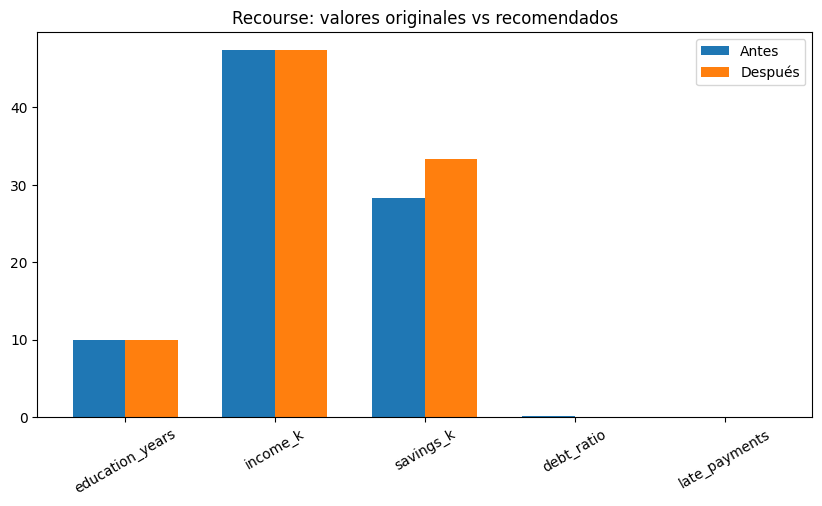

In [ ]:
# ============================================
# CELDA 11. GRÁFICO ANTES VS DESPUÉS
# ============================================

plot_features = list(actionable_features.keys())

before_vals = [person[f] for f in plot_features]
after_vals = [best_recourse["candidate"][f] for f in plot_features]

x = np.arange(len(plot_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, before_vals, width, label="Antes")
plt.bar(x + width/2, after_vals, width, label="Después")
plt.xticks(x, plot_features, rotation=30)
plt.title("Recourse: valores originales vs recomendados")
plt.legend()
plt.show()


## 12. Extensión temporal: el recourse puede vencerse

Esto conecta con la idea de *temporal recourse*: una recomendación útil hoy puede dejar de servir mañana.


In [ ]:
# ============================================
# CELDA 12. CHEQUEO TEMPORAL DEL RECOURSE
# ============================================

def temporal_check(candidate_row, model, feature_names,
                   income_drop=5,
                   debt_increase=0.08,
                   late_payment_increase=1):
    """
    Simula un escenario futuro adverso.
    """
    future = candidate_row.copy()

    future["income_k"] = max(10, future["income_k"] - income_drop)
    future["debt_ratio"] = min(0.95, future["debt_ratio"] + debt_increase)
    future["late_payments"] = min(8, future["late_payments"] + late_payment_increase)

    p_now = model.predict_proba(pd.DataFrame([candidate_row[feature_names]]))[0, 1]
    p_future = model.predict_proba(pd.DataFrame([future[feature_names]]))[0, 1]

    return round(float(p_now), 4), round(float(p_future), 4), future

p_now, p_future, future_case = temporal_check(
    best_recourse["candidate"],
    model,
    feature_names,
    income_drop=5,
    debt_increase=0.08,
    late_payment_increase=1
)

print("Probabilidad justo después del recourse:", p_now)
print("Probabilidad en un escenario futuro adverso:", p_future)

print("\nCaso futuro simulado:")
display(future_case.to_frame(name="future_value"))


Probabilidad justo después del recourse: 0.6313
Probabilidad en un escenario futuro adverso: 0.2172

Caso futuro simulado:


,future_value
age,43.000
education_years,10.000
income_k,42.400
savings_k,33.300
debt_ratio,0.130
late_payments,1.000
dependents,1.000


## Chequeo temporal del *recourse* e interpretación de los resultados

Esta sección introduce una idea muy importante en *algorithmic recourse*: una recomendación puede funcionar **hoy**, pero dejar de funcionar **mañana** si las condiciones cambian. Por eso, aquí no se pregunta solamente si el *recourse* logró cambiar la predicción en el momento actual, sino también si esa mejora es **estable en el tiempo**.

La lógica de esta celda es simular un escenario futuro adverso y verificar si la solución recomendada sigue siendo suficiente para mantener una predicción positiva.

### Qué hace la función `temporal_check`

La función `temporal_check` recibe como entrada:

- `candidate_row`: el caso ya modificado por el *recourse*,
- `model`: el modelo entrenado,
- `feature_names`: la lista de variables del modelo,
- y tres parámetros que representan un deterioro futuro:
  - `income_drop=5`
  - `debt_increase=0.08`
  - `late_payment_increase=1`

La función parte del caso recomendado y construye una nueva versión llamada `future`, que representa un posible escenario adverso en el futuro.

### Qué cambios se simulan

La simulación aplica tres modificaciones:

- `income_k` disminuye en 5 unidades.
- `debt_ratio` aumenta en 0.08.
- `late_payments` aumenta en 1 unidad.

Además, el código impone límites para evitar valores imposibles:

- el ingreso no puede bajar de 10,
- el ratio de deuda no puede superar 0.95,
- los pagos tardíos no pueden superar 8.

La idea conceptual es esta: después de aplicar el *recourse*, puede ocurrir que la situación de la persona empeore un poco. Entonces el notebook prueba si, aun con ese deterioro, la recomendación sigue sosteniendo una predicción favorable.

### Qué devuelve la función

La función devuelve tres elementos:

- `p_now`: la probabilidad del caso justo después del *recourse*,
- `p_future`: la probabilidad en el escenario futuro adverso,
- `future`: el nuevo caso simulado con los valores deteriorados.

En otras palabras, compara el presente corregido con un futuro menos favorable.

### Interpretación de los resultados obtenidos

Los resultados fueron:

- **Probabilidad justo después del recourse: `0.6313`**
- **Probabilidad en un escenario futuro adverso: `0.2172`**

Y el caso futuro simulado quedó así:

- `age = 43.000`
- `education_years = 10.000`
- `income_k = 42.400`
- `savings_k = 33.300`
- `debt_ratio = 0.130`
- `late_payments = 1.000`
- `dependents = 1.000`

### Lectura sustantiva del caso futuro

Comparado con el caso recomendado por el *recourse*, el escenario futuro mantiene iguales varias variables:

- `age` no cambia,
- `education_years` no cambia,
- `savings_k` no cambia,
- `dependents` no cambia.

Pero sí introduce tres deterioros:

- el ingreso baja de `47.400` a `42.400`,
- el ratio de deuda sube de `0.050` a `0.130`,
- los pagos tardíos suben de `0.000` a `1.000`.

Estos cambios son suficientes para que la probabilidad caiga de `0.6313` a `0.2172`.

### Qué significa esa caída de probabilidad

La caída es muy fuerte. La recomendación inicialmente dejaba al caso con una probabilidad relativamente cómoda por encima del umbral de 0.5. Sin embargo, bajo el shock simulado, la probabilidad cae muy por debajo del umbral.

Eso significa que la solución encontrada por el *recourse* era **efectiva en el presente**, pero **frágil ante cambios adversos posteriores**.

Dicho de otra manera:

- el *recourse* logró cambiar la predicción,
- pero no construyó un margen de seguridad lo suficientemente amplio como para resistir un deterioro moderado en las condiciones del caso.

### Interpretación metodológica

Esta sección ilustra la idea de **validez temporal del recourse**.

Una recomendación de *recourse* puede ser:

- **válida en el corto plazo**, porque cruza el umbral del modelo,
- pero **inestable en el mediano plazo**, porque pequeños cambios en el entorno la hacen colapsar.

Esto es importante porque, en aplicaciones reales, muchas variables no permanecen fijas. El ingreso puede fluctuar, el endeudamiento puede aumentar, y la conducta de pago puede empeorar. Si una solución solo funciona en una fotografía estática, entonces puede ser poco útil como recomendación práctica.

### Por qué esta sección es importante

Sin este chequeo temporal, uno podría concluir que el *recourse* fue exitoso simplemente porque cambió la predicción. Sin embargo, esta celda muestra que eso no basta. También es necesario preguntarse:

- ¿la recomendación sigue funcionando si el contexto cambia un poco?
- ¿o era apenas una solución que cruzaba el umbral por muy poco?

Por eso, esta parte del notebook amplía la evaluación del *recourse*: no solo analiza si la recomendación funciona, sino también **qué tan resistente es en el tiempo**.


## 13. Introducir plausibilidad y acción parcial

En la vida real, no basta con que un cambio sea matemáticamente suficiente. También debería ser:

- **plausible**,
- **consistente con el contexto**,
- y en algunos casos solo **parcialmente accionable**.

Aquí añadimos restricciones heurísticas, no causales, para ilustrar la idea:
- la educación no puede subir demasiado de golpe,
- una gran mejora en ahorros debería venir acompañada de alguna mejora en ingresos,
- una gran reducción de deuda no debería aparecer como magia de una noche.


In [ ]:
# ============================================
# CELDA 13. RESTRICCIONES DE PLAUSIBILIDAD
# ============================================

def is_plausible_candidate(original, candidate):
    income_delta = float(candidate["income_k"] - original["income_k"])
    savings_delta = float(candidate["savings_k"] - original["savings_k"])
    debt_improvement = float(original["debt_ratio"] - candidate["debt_ratio"])
    late_improvement = float(original["late_payments"] - candidate["late_payments"])
    education_delta = float(candidate["education_years"] - original["education_years"])

    rules = []

    # No asumir saltos educativos demasiado abruptos
    rules.append(education_delta <= 2)

    # Si aumentan mucho los ahorros, debería haber al menos una mejora modesta en ingresos
    rules.append(not (savings_delta > 15 and income_delta < 5))

    # Una fuerte reducción en deuda debería estar respaldada por ingresos o ahorros
    rules.append(not (debt_improvement > 0.10 and income_delta < 5 and savings_delta < 5))

    # Una fuerte mejora en pagos tardíos debería venir acompañada de alguna mejora financiera
    rules.append(not (late_improvement >= 2 and income_delta == 0 and savings_delta == 0))

    return all(rules)


def find_recourse_filtered(person_row, model, feature_names, actionable_features, plausibility_fn=None):
    value_grid = {
        f: build_candidate_values(float(person_row[f]), cfg)
        for f, cfg in actionable_features.items()
    }

    candidates = []

    for values in product(*[value_grid[f] for f in actionable_features.keys()]):
        candidate = person_row.copy()

        for f, v in zip(actionable_features.keys(), values):
            candidate[f] = v

        if plausibility_fn is not None and not plausibility_fn(person_row, candidate):
            continue

        x_candidate = pd.DataFrame([candidate[feature_names]])
        prob = model.predict_proba(x_candidate)[0, 1]
        pred = int(prob >= 0.5)

        if pred == 1:
            total_cost, cost_detail = recourse_cost(person_row, candidate, actionable_features)

            candidates.append({
                "prob_approve": round(float(prob), 4),
                "total_cost": total_cost,
                "candidate": candidate.copy(),
                "cost_detail": cost_detail
            })

    if len(candidates) == 0:
        return None, []

    candidates = sorted(candidates, key=lambda x: (x["total_cost"], -x["prob_approve"]))
    return candidates[0], candidates


plausible_recourse, plausible_candidates = find_recourse_filtered(
    person_row=person,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate
)

print("Número de soluciones plausibles encontradas:", len(plausible_candidates))
print("\nMejor solución plausible:")
print(plausible_recourse)


Número de soluciones plausibles encontradas: 359

Mejor solución plausible:
{'prob_approve': 0.6313, 'total_cost': np.float64(2.0), 'candidate': age               43.000
education_years   10.000
income_k          47.400
savings_k         33.300
debt_ratio         0.050
late_payments      0.000
dependents         1.000
Name: 305, dtype: float64, 'cost_detail': {'education_years': np.float64(0.0), 'income_k': np.float64(0.0), 'savings_k': np.float64(0.8), 'debt_ratio': np.float64(1.2), 'late_payments': np.float64(0.0)}}


## Restricciones de plausibilidad y búsqueda de *recourse* filtrado

En esta sección se introduce una idea clave para hacer el *recourse* más realista: no basta con que una recomendación logre cambiar la predicción del modelo, también debería ser **plausible** desde el punto de vista sustantivo.

Hasta este punto, el notebook encontraba combinaciones de cambios que eran matemáticamente válidas y respetaban las reglas de *actionability*. Sin embargo, aun dentro de esas reglas, pueden aparecer soluciones poco creíbles en la práctica. Por ejemplo, podría encontrarse una combinación donde aumentan mucho los ahorros sin que haya ninguna mejora en ingresos, o una caída fuerte de deuda sin una explicación financiera razonable.

Por eso, esta celda añade un segundo filtro: además de ser **accionable**, una solución debe ser también **plausible**.

### Función `is_plausible_candidate`

La función `is_plausible_candidate(original, candidate)` compara el caso original con un caso candidato y evalúa si los cambios propuestos cumplen ciertas reglas heurísticas de plausibilidad.

Para hacerlo, primero calcula cinco diferencias:

- `income_delta`: cuánto aumenta el ingreso.
- `savings_delta`: cuánto aumentan los ahorros.
- `debt_improvement`: cuánto mejora el ratio de deuda.
- `late_improvement`: cuánto mejoran los pagos tardíos.
- `education_delta`: cuánto aumentan los años de educación.

Estas cantidades sirven para revisar si los cambios propuestos mantienen cierta coherencia.

### Reglas de plausibilidad

La función define una lista de reglas y luego exige que **todas** se cumplan.

#### 1. No asumir saltos educativos demasiado abruptos

Se impone que:

- `education_delta <= 2`

Esto significa que el número de años de educación no puede aumentar en más de dos unidades. La idea es evitar recomendaciones como “sume cuatro años de educación” si eso resulta poco verosímil en el horizonte temporal implícito del problema.

#### 2. Si aumentan mucho los ahorros, debería haber al menos una mejora modesta en ingresos

Se descarta cualquier candidato en el que:

- los ahorros aumenten más de 15,
- pero el ingreso aumente menos de 5.

La lógica es que un salto importante en ahorros sin ninguna mejora en ingresos puede ser poco creíble. No es imposible, pero el notebook lo trata como una señal de poca plausibilidad.

#### 3. Una fuerte reducción de deuda debería estar respaldada por ingresos o ahorros

Se descarta cualquier candidato en el que:

- la mejora en deuda sea mayor a 0.10,
- y al mismo tiempo no haya una mejora de al menos 5 en ingresos,
- ni una mejora de al menos 5 en ahorros.

La idea aquí es que una reducción fuerte de deuda no debería aparecer “de la nada”. Si la deuda mejora mucho, debería existir alguna mejora financiera que la respalde.

#### 4. Una fuerte mejora en pagos tardíos debería venir acompañada de alguna mejora financiera

Se descarta cualquier candidato en el que:

- los pagos tardíos mejoren en 2 o más unidades,
- pero no haya ningún aumento ni en ingresos ni en ahorros.

Esta regla intenta evitar soluciones donde la conducta de pago mejora mucho sin ningún cambio que haga esa mejora razonable.

### Resultado de `is_plausible_candidate`

La función devuelve `all(rules)`, es decir:

- `True` si todas las reglas se cumplen,
- `False` si al menos una falla.

Por tanto, esta función actúa como un filtro adicional que separa las soluciones simplemente posibles de las soluciones además plausibles.

### Función `find_recourse_filtered`

La función `find_recourse_filtered(...)` es una extensión de la función anterior de búsqueda de *recourse*. Su lógica general es la misma:

1. Construye la grilla de valores posibles para cada variable accionable.
2. Genera todas las combinaciones posibles.
3. Evalúa cada combinación con el modelo.
4. Conserva solo las que cambian la predicción a positiva.
5. Calcula el costo de cada solución.
6. Ordena las soluciones por costo y luego por probabilidad.

La diferencia importante es que ahora incluye este paso adicional:

- si existe una función de plausibilidad (`plausibility_fn`) y el candidato no la cumple, la combinación se descarta antes de ser evaluada por el modelo.

En otras palabras, el algoritmo ya no busca solo soluciones que funcionen, sino soluciones que funcionen **y además pasen el filtro de plausibilidad**.

### Ejecución del filtro de plausibilidad

En esta celda se llama a la función así:

- `person_row = person`
- `model = model`
- `feature_names = feature_names`
- `actionable_features = actionable_features`
- `plausibility_fn = is_plausible_candidate`

Eso significa que la búsqueda se hace sobre el mismo caso analizado antes, pero ahora imponiendo el conjunto de reglas heurísticas de plausibilidad.

### Interpretación de los resultados

El resultado mostrado fue:

- **Número de soluciones plausibles encontradas: `359`**
- y la mejor solución plausible fue:

  - `prob_approve = 0.6313`
  - `total_cost = 2.0`

  con el siguiente caso recomendado:

  - `age = 43.000`
  - `education_years = 10.000`
  - `income_k = 47.400`
  - `savings_k = 33.300`
  - `debt_ratio = 0.050`
  - `late_payments = 0.000`
  - `dependents = 1.000`

  y el siguiente detalle de costo:

  - `education_years = 0.0`
  - `income_k = 0.0`
  - `savings_k = 0.8`
  - `debt_ratio = 1.2`
  - `late_payments = 0.0`

### Qué significa que haya 359 soluciones plausibles

Antes del filtro de plausibilidad se habían encontrado más soluciones válidas. Ahora, después del filtro, ese conjunto se redujo a **359 soluciones plausibles**.

Esto significa que varias de las soluciones matemáticamente válidas fueron descartadas por no cumplir criterios razonables de coherencia.

La lectura metodológica es importante:

- el espacio de soluciones posibles se reduce,
- pero las soluciones que quedan son más defendibles desde el punto de vista sustantivo.

### Qué significa que la mejor solución plausible sea la misma

Lo más interesante del resultado es que, aunque el número total de soluciones se redujo, la **mejor solución plausible coincide con la mejor solución encontrada antes**.

Eso quiere decir que la recomendación de menor costo que ya habíamos identificado no solo era matemáticamente efectiva, sino también razonablemente plausible bajo las reglas definidas.

En este caso, el filtro de plausibilidad no cambió la mejor recomendación, pero sí eliminó muchas otras alternativas menos creíbles.

### Lectura sustantiva del resultado

La mejor solución plausible sigue consistiendo en:

- aumentar `savings_k` de `28.3` a `33.3`,
- reducir `debt_ratio` de `0.09` a `0.05`,
- sin modificar educación, ingreso, pagos tardíos, edad ni dependientes.

La probabilidad final se mantiene en `0.6313`, y el costo total sigue siendo `2.0`.

Esto sugiere que la recomendación encontrada tiene una doble fortaleza:

- funciona para cambiar la predicción,
- y además no viola las reglas heurísticas de plausibilidad impuestas.

## 14. Evaluación en lote sobre varios casos rechazados

Ahora pasamos de un solo caso a una pequeña **mini-población** de casos rechazados.

Esto nos permite responder preguntas como:
- ¿con qué frecuencia encontramos recourse?
- ¿qué tan costoso suele ser?
- ¿cuánto sube, en promedio, la probabilidad?
- ¿cuánto cambia el panorama cuando imponemos plausibilidad?


In [ ]:
# ============================================
# CELDA 14. EVALUACIÓN EN LOTE
# ============================================

def evaluate_recourse_batch(rejected_df, model, feature_names, actionable_features, plausibility_fn=None, max_cases=40):
    rows = []

    sample_df = rejected_df.head(max_cases).copy()

    for idx, row in sample_df.iterrows():
        person_row = row[feature_names].copy()
        base_prob = float(model.predict_proba(pd.DataFrame([person_row]))[0, 1])

        best, _ = find_recourse_filtered(
            person_row=person_row,
            model=model,
            feature_names=feature_names,
            actionable_features=actionable_features,
            plausibility_fn=plausibility_fn
        )

        result = {
            "index": idx,
            "base_prob": base_prob,
            "found_recourse": best is not None
        }

        if best is not None:
            result["new_prob"] = best["prob_approve"]
            result["prob_gain"] = best["prob_approve"] - base_prob
            result["total_cost"] = best["total_cost"]
            result["age"] = person_row["age"]
            result["dependents"] = person_row["dependents"]
        else:
            result["new_prob"] = np.nan
            result["prob_gain"] = np.nan
            result["total_cost"] = np.nan
            result["age"] = person_row["age"]
            result["dependents"] = person_row["dependents"]

        rows.append(result)

    return pd.DataFrame(rows)

batch_free = evaluate_recourse_batch(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=None,
    max_cases=40
)

batch_plausible = evaluate_recourse_batch(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate,
    max_cases=40
)

summary_batch = pd.DataFrame([
    {
        "scenario": "Libre",
        "n_cases": len(batch_free),
        "success_rate": batch_free["found_recourse"].mean(),
        "avg_cost_successes": batch_free.loc[batch_free["found_recourse"], "total_cost"].mean(),
        "avg_prob_gain_successes": batch_free.loc[batch_free["found_recourse"], "prob_gain"].mean()
    },
    {
        "scenario": "Plausible",
        "n_cases": len(batch_plausible),
        "success_rate": batch_plausible["found_recourse"].mean(),
        "avg_cost_successes": batch_plausible.loc[batch_plausible["found_recourse"], "total_cost"].mean(),
        "avg_prob_gain_successes": batch_plausible.loc[batch_plausible["found_recourse"], "prob_gain"].mean()
    }
])

display(summary_batch)


,scenario,n_cases,success_rate,avg_cost_successes,avg_prob_gain_successes
0,Libre,40,1.000,1.540,0.218
1,Plausible,40,1.000,1.540,0.218


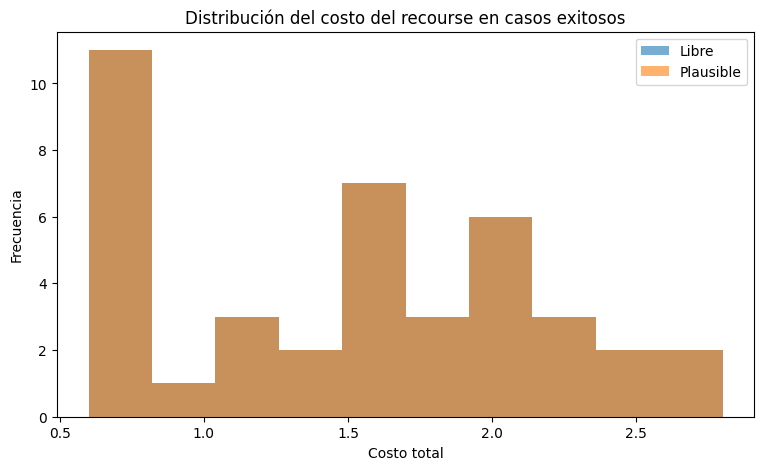

In [ ]:
# ============================================
# CELDA 15. VISUALIZAR COSTOS EN LOTE
# ============================================

plt.figure(figsize=(9, 5))
plt.hist(batch_free.loc[batch_free["found_recourse"], "total_cost"].dropna(), alpha=0.6, label="Libre")
plt.hist(batch_plausible.loc[batch_plausible["found_recourse"], "total_cost"].dropna(), alpha=0.6, label="Plausible")
plt.title("Distribución del costo del recourse en casos exitosos")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

def interpret_batch_results(summary_batch):
    free_row = summary_batch[summary_batch["scenario"] == "Libre"].iloc[0]
    plausible_row = summary_batch[summary_batch["scenario"] == "Plausible"].iloc[0]

    text = []
    text.append("### Interpretación de la evaluación en lote")
    text.append(f"- En el escenario libre, la tasa de éxito es **{free_row['success_rate']:.2%}**.")
    text.append(f"- En el escenario plausible, la tasa de éxito es **{plausible_row['success_rate']:.2%}**.")
    text.append(f"- El costo promedio entre los éxitos pasa de **{free_row['avg_cost_successes']:.3f}** a **{plausible_row['avg_cost_successes']:.3f}**.")
    text.append(f"- La ganancia promedio de probabilidad pasa de **{free_row['avg_prob_gain_successes']:.3f}** a **{plausible_row['avg_prob_gain_successes']:.3f}**.")
    text.append("- Si la plausibilidad reduce la tasa de éxito, eso es normal: muchas rutas baratas eran matemáticamente útiles, pero poco realistas.")
    text.append("- Si además aumenta el costo promedio, eso sugiere que las soluciones más creíbles suelen exigir esfuerzos mayores.")

interpret_batch_results(summary_batch)


## 16. Robustez temporal en lote

Una buena recomendación no solo debe funcionar **hoy**. También conviene preguntarse:

- ¿sigue funcionando si el contexto cambia un poco?
- ¿se mantiene la aprobación después de un shock razonable?
- ¿o era una solución demasiado frágil?

Aquí evaluamos la robustez temporal de los recourses plausibles.


In [ ]:
# ============================================
# CELDA 16. ROBUSTEZ TEMPORAL EN LOTE
# ============================================

def collect_successful_recourse_objects(rejected_df, model, feature_names, actionable_features, plausibility_fn=None, max_cases=40):
    rows = []
    sample_df = rejected_df.head(max_cases).copy()

    for idx, row in sample_df.iterrows():
        person_row = row[feature_names].copy()

        best, _ = find_recourse_filtered(
            person_row=person_row,
            model=model,
            feature_names=feature_names,
            actionable_features=actionable_features,
            plausibility_fn=plausibility_fn
        )

        if best is not None:
            rows.append({
                "index": idx,
                "person": person_row,
                "recourse": best["candidate"],
                "prob_after": best["prob_approve"],
                "cost": best["total_cost"]
            })

    return rows

successful_plausible = collect_successful_recourse_objects(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate,
    max_cases=40
)

temporal_rows = []

for item in successful_plausible:
    p_now, p_future, future_case = temporal_check(
        item["recourse"],
        model,
        feature_names,
        income_drop=5,
        debt_increase=0.08,
        late_payment_increase=1
    )

    temporal_rows.append({
        "index": item["index"],
        "prob_after": p_now,
        "prob_future": p_future,
        "drop": p_now - p_future,
        "remains_approved": p_future >= 0.5,
        "cost": item["cost"]
    })

temporal_df = pd.DataFrame(temporal_rows)
display(temporal_df.head())

if len(temporal_df) > 0:
    temporal_summary = pd.DataFrame([{
        "n_successful_recourse": len(temporal_df),
        "share_remaining_approved": temporal_df["remains_approved"].mean(),
        "avg_probability_drop": temporal_df["drop"].mean()
    }])
else:
    temporal_summary = pd.DataFrame([{
        "n_successful_recourse": 0,
        "share_remaining_approved": np.nan,
        "avg_probability_drop": np.nan
    }])

display(temporal_summary)


,index,prob_after,prob_future,drop,remains_approved,cost
0,36,0.533,0.156,0.377,False,1.200
1,253,0.521,0.150,0.371,False,0.900
2,707,0.507,0.143,0.364,False,0.600
3,505,0.608,0.201,0.407,False,0.800
4,84,0.600,0.196,0.404,False,0.800


,n_successful_recourse,share_remaining_approved,avg_probability_drop
0,40,0.000,0.385


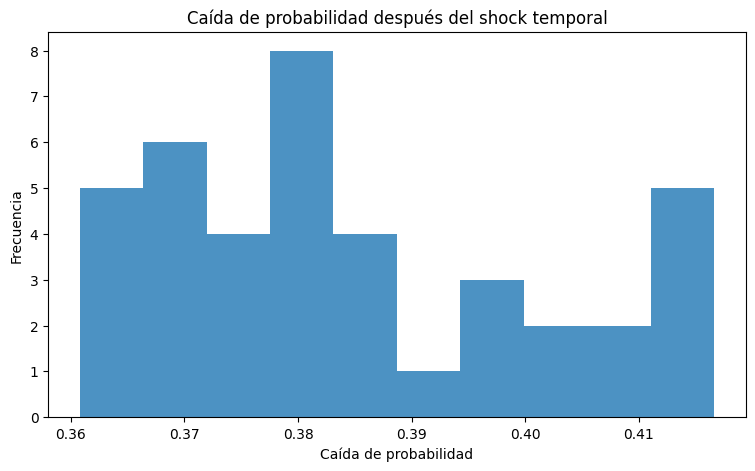

In [ ]:
# ============================================
# CELDA 17. INTERPRETAR ROBUSTEZ TEMPORAL
# ============================================

if len(temporal_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.hist(temporal_df["drop"], alpha=0.8)
    plt.title("Caída de probabilidad después del shock temporal")
    plt.xlabel("Caída de probabilidad")
    plt.ylabel("Frecuencia")
    plt.show()

def interpret_temporal_results(temporal_summary):
    row = temporal_summary.iloc[0]

    text = []
    text.append("### Interpretación temporal")

    if row["n_successful_recourse"] == 0:
        text.append("- No hubo recourses plausibles exitosos para evaluar robustez temporal.")
    else:
        text.append(f"- Se evaluaron **{int(row['n_successful_recourse'])}** casos con recourse plausible exitoso.")
        text.append(f"- La proporción que se mantiene aprobada después del shock es **{row['share_remaining_approved']:.2%}**.")
        text.append(f"- La caída promedio de probabilidad es **{row['avg_probability_drop']:.3f}**.")
        text.append("- Si muchas recomendaciones dejan de funcionar tras un pequeño shock, el recourse es frágil.")
        text.append("- Si la mayoría sobrevive, eso sugiere que las recomendaciones no solo cruzan el umbral, sino que crean cierto margen de seguridad.")

interpret_temporal_results(temporal_summary)


# Instalar y correr DiCE sobre tu caso actual

In [ ]:
# ============================================
# CELDA 18. DICE SOBRE EL NOTEBOOK ACTUAL
# ============================================

!pip -q install dice-ml

import dice_ml

# 1. Crear la instancia a explicar
query_instance = pd.DataFrame([person[feature_names]])

# 2. Definir rangos permitidos a partir de tus reglas de actionability
permitted_range = {
    f: [cfg["min_value"], cfg["max_value"]]
    for f, cfg in actionable_features.items()
}

# 3. Definir el objeto de datos para DiCE
# Como todas tus variables son numéricas, las tratamos como continuas
data_dice = dice_ml.Data(
    dataframe=df.copy(),
    continuous_features=feature_names,
    outcome_name="approved"
)

# 4. Envolver tu modelo sklearn ya entrenado
model_dice = dice_ml.Model(
    model=model,
    backend="sklearn"
)

# 5. Crear el generador de contrafactuales
# Puedes probar "random" o "genetic"; aquí usamos "genetic"
# porque suele dar soluciones más cuidadas
exp = dice_ml.Dice(
    data_dice,
    model_dice,
    method="genetic"
)

# 6. Generar contrafactuales
dice_result = exp.generate_counterfactuals(
    query_instances=query_instance,
    total_CFs=4,
    desired_class="opposite",
    features_to_vary=list(actionable_features.keys()),
    permitted_range=permitted_range
)

# 7. Visualizar solo los cambios
dice_result.visualize_as_dataframe(show_only_changes=True)

# 8. Extraer DataFrame final para usarlo después
dice_df = dice_result.cf_examples_list[0].final_cfs_df.copy()

print("Contrafactuales generados por DiCE:")
display(dice_df)

100%|██████████| 1/1 [00:00<00:00,  7.44it/s]

Query instance (original outcome : 0)


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,approved
0,43.000,10.000,47.400,28.300,0.090,0.000,1.000,0



Diverse Counterfactual set (new outcome: 1)


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,approved
0,-,-,54.7,33.8,0.12,-,-,1.0
0,-,-,59.4,35.3,0.12,-,-,1.0
0,-,-,52.8,34.7,0.04,-,-,1.0
0,-,-,55.2,34.7,0.04,-,-,1.0


Contrafactuales generados por DiCE:


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,approved
0,43.000,10.000,54.700,33.800,0.120,0.000,1.000,1
0,43.000,10.000,59.400,35.300,0.120,0.000,1.000,1
0,43.000,10.000,52.800,34.700,0.040,0.000,1.000,1
0,43.000,10.000,55.200,34.700,0.040,0.000,1.000,1


# Calcular costo de los contrafactuales de DiCE con tu misma métrica

In [ ]:
# ============================================
# CELDA 19. EVALUAR LOS CF DE DICE CON TU MÉTRICA
# ============================================

dice_eval_rows = []

if dice_df is not None and len(dice_df) > 0:
    for i, (_, row) in enumerate(dice_df.iterrows(), start=1):
        candidate = row[feature_names].copy()

        # Probabilidad con tu modelo original
        prob_candidate = float(model.predict_proba(pd.DataFrame([candidate]))[0, 1])

        # Costo usando tu función manual
        total_cost, cost_detail = recourse_cost(
            original=person,
            candidate=candidate,
            actionable_features=actionable_features
        )

        # Resumen de cambios
        changed_features = [
            f for f in feature_names
            if abs(float(candidate[f] - person[f])) > 1e-9
        ]

        dice_eval_rows.append({
            "cf_rank": i,
            "prob_approve": round(prob_candidate, 4),
            "total_cost_manual_metric": float(total_cost),
            "n_changed_features": len(changed_features),
            "changed_features": ", ".join(changed_features),
            "cost_detail": str(cost_detail)
        })

    dice_eval_df = pd.DataFrame(dice_eval_rows)
    display(dice_eval_df)
else:
    print("DiCE no devolvió contrafactuales.")

,cf_rank,prob_approve,total_cost_manual_metric,n_changed_features,changed_features,cost_detail
0,1,0.752,2.340,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."
1,2,0.863,3.520,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."
2,3,0.800,3.604,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."
3,4,0.841,4.084,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."


# Comparar el mejor recourse manual vs el mejor contrafactual de DiCE

In [ ]:
# ============================================
# CELDA 20. COMPARACIÓN MANUAL VS DICE
# ============================================

comparison_rows = []

# Mejor solución manual
if best_recourse is not None:
    comparison_rows.append({
        "method": "Manual grid search",
        "prob_approve": best_recourse["prob_approve"],
        "total_cost": float(best_recourse["total_cost"]),
        "n_changed_features": int(sum(
            abs(float(best_recourse["candidate"][f] - person[f])) > 1e-9
            for f in feature_names
        ))
    })

# Mejor solución de DiCE según tu métrica de costo
if "dice_eval_df" in globals() and len(dice_eval_df) > 0:
    best_dice_idx = dice_eval_df["total_cost_manual_metric"].idxmin()
    best_dice_row = dice_eval_df.loc[best_dice_idx]

    comparison_rows.append({
        "method": "DiCE",
        "prob_approve": best_dice_row["prob_approve"],
        "total_cost": best_dice_row["total_cost_manual_metric"],
        "n_changed_features": best_dice_row["n_changed_features"]
    })

comparison_methods_df = pd.DataFrame(comparison_rows)
display(comparison_methods_df)

,method,prob_approve,total_cost,n_changed_features
0,Manual grid search,0.631,2.000,2
1,DiCE,0.752,2.340,3


# Ver exactamente qué cambia en el mejor contrafactual de DiCE

In [ ]:
# ============================================
# CELDA 21. RESUMEN HUMANO DEL MEJOR CF DE DICE
# ============================================

if "dice_eval_df" in globals() and len(dice_eval_df) > 0:
    best_dice_idx = dice_eval_df["total_cost_manual_metric"].idxmin()
    best_dice_candidate = dice_df.iloc[best_dice_idx][feature_names].copy()

    summary_rows_dice = []
    for f in feature_names:
        summary_rows_dice.append({
            "feature": f,
            "original": person[f],
            "dice_recommended": best_dice_candidate[f],
            "delta": round(float(best_dice_candidate[f] - person[f]), 3)
        })

    summary_dice_df = pd.DataFrame(summary_rows_dice)
    display(summary_dice_df)

    print("Probabilidad original:",
          round(float(model.predict_proba(pd.DataFrame([person]))[0, 1]), 4))
    print("Probabilidad con mejor CF de DiCE:",
          round(float(model.predict_proba(pd.DataFrame([best_dice_candidate]))[0, 1]), 4))
else:
    print("No hay contrafactuales de DiCE para resumir.")

,feature,original,dice_recommended,delta
0,age,43.000,43.000,0.000
1,education_years,10.000,10.000,0.000
2,income_k,47.400,54.700,7.300
3,savings_k,28.300,33.800,5.500
4,debt_ratio,0.090,0.120,0.030
5,late_payments,0.000,0.000,0.000
6,dependents,1.000,1.000,0.000


Probabilidad original: 0.4347
Probabilidad con mejor CF de DiCE: 0.7516
